# **IDENTIFICATION THRESHOLD**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys

!pip install facenet-pytorch

src_path = "/content/drive/MyDrive/11/src"

if src_path not in sys.path:
    sys.path.append(src_path)

import os
import torch
from sklearn.model_selection import train_test_split
from identification_system import IdentificationSystem

### **Valutazione Sistema di Identificazione (Open-Set 1:N)**

Questa sezione analizza lo scenario più complesso: **Open-Set Identification**.
Il sistema riceve un volto (Probe) e deve rispondere a due domande:
1.  **"Chi è?"** (Cerca il volto più simile nella Gallery).
2.  **"È iscritto?"** (Decide se la somiglianza è sufficiente o se è uno sconosciuto).

Il processo garantisce l'assenza di **Data Leakage** separando i dati:
1.  **Calibrazione Soglia ($T_i$):**
    * Si utilizza il **40%** dei Probe (Validation Set) per simulare tentativi di accesso.
    * Si analizza la distribuzione dei punteggi degli "Sconosciuti/Impostori" e si fissa una soglia $T_i$ tale che il **FAR (False Acceptance Rate)** sia limitato al **1%** (`target_far=0.01`).
2.  **Test Finale:**
    * Si applica $T_i$ al restante **60%** (Test Set).
    * Vengono misurate le performance reali: **DIR** (Detection & Identification Rate, ovvero quanti utenti iscritti vengono riconosciuti correttamente) e il FAR effettivo su nuovi dati.

In [ ]:
def get_probe_split_lists(probes_root_path, val_size=0.4, random_seed=42):
    """
    Restituisce liste separate di Path e Label per Train e Test.
    Include sorted() per garantire la corrispondenza con la classe IdentificationSystem.
    """
    all_files = []
    all_labels = []

    if not os.path.exists(probes_root_path): return [], [], [], []

    subjects = sorted([d for d in os.listdir(probes_root_path) if os.path.isdir(os.path.join(probes_root_path, d))])

    for subject_dir in subjects:
        subject_path = os.path.join(probes_root_path, subject_dir)
        if "subject_" in subject_dir:
            try:
                label = int(subject_dir.split('_')[1])
                files = sorted([f for f in os.listdir(subject_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

                for fname in files:
                    all_files.append(os.path.join(subject_path, fname))
                    all_labels.append(label)
            except:
                continue

    if not all_files: return [], [], [], []

    X_train, X_test, y_train, y_test = train_test_split(
        all_files, all_labels,
        test_size=(1 - val_size),
        stratify=all_labels,
        random_state=random_seed
    )
    return X_train, X_test, y_train, y_test

--- Identification Task su cpu ---
Inizializzazione Modello su cpu...
ATTENZIONE: Nessun peso custom trovato/fornito. Uso VGGFace2 standard.

Caricamento Gallery da file: /content/drive/MyDrive/11/features_labels_gr_11 e /content/drive/MyDrive/11/features_embeddings_gr_11...
Gallery caricata: 160 soggetti.

--- Inizio Calcolo Soglia Identification (Ti) ---
Target FAR richiesto: 1.0%
Validation Set per Ti: 143 immagini (Impostori simulati)

--- RISULTATI CALCOLO SOGLIA ---
Soglia Calcolata (Ti): 0.7903


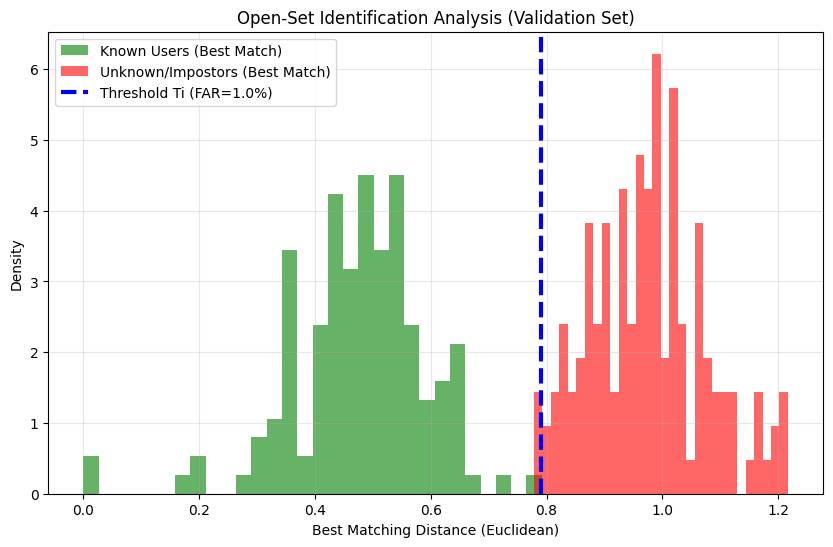

Verifica FAR: 1.40%
DIR stimato: 99.30%

Recupero Test Set...

--- VALUTAZIONE TEST SET (Open-Set) ---
Soglia Ti usata: 0.7903
----------------------------------------
METRICHE ISCRITTI:
  DIR: 99.54%
  FRR: 0.46%
----------------------------------------
METRICHE SCONOSCIUTI:
  FAR: 0.00%

[IMPORTANTE] Salva 0.7903 come tua soglia Ti.


In [ ]:
PATH_GALLERY_EMB_PREFIX = "/content/drive/MyDrive/11/features_embeddings_gr_11"
PATH_GALLERY_LBL_PREFIX = "/content/drive/MyDrive/11/features_labels_gr_11"
PATH_PROBES_DIR = "/content/drive/MyDrive/BBA_Dataset_processed/probes"


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"--- Identification Task su {device} ---")

id_system = IdentificationSystem(device)

if os.path.exists(f"{PATH_GALLERY_EMB_PREFIX}.npy"):
    id_system.load_existing_gallery(PATH_GALLERY_EMB_PREFIX, PATH_GALLERY_LBL_PREFIX)
else:
    print("ERRORE: Gallery non trovata.")
    exit()

if os.path.exists(PATH_PROBES_DIR):
    ti = id_system.compute_identification_threshold(PATH_PROBES_DIR, val_split=0.4, target_far=0.01, random_seed=42)

    if ti is not None:
        print("\nRecupero Test Set...")
        _, X_test, _, y_test = get_probe_split_lists(PATH_PROBES_DIR, val_size=0.4, random_seed=42)

        id_system.evaluate_open_set_test(X_test, y_test, ti)

        print(f"\n[IMPORTANTE] Salva {ti:.4f} come tua soglia Ti.")